# Eda on Time Serie (Product)

In this notebook we do a quick time series EDA to understand how demand behaves over time.

We will:
1.	Plot a few product time series (trend + peaks).
2.	Plot weekday seasonality (average demand by Monday/Tuesday/…).
3.	Plot ACF / PACF on 1–2 series to illustrate short-term dependence and weekly seasonality.
4.	Export 3 or 4 figures into a reports/figures/ folder.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Create folder to export figures
FIG_DIR = "reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

Figures will be saved in: reports/figures


## Load product time series (qty_ts, rev_ts)

We load the daily time series produced in Step 2:
	•	qty_ts: daily quantities sold per product (12 columns)
	•	rev_ts: daily revenue per product (12 columns)

In [4]:
# Load qty_ts and rev_ts from CSV (recommended)
# Adjust paths if needed
qty_path = "data_tmp/qty_ts.csv"
rev_path = "data_tmp/rev_ts.csv"

qty_ts = pd.read_csv(qty_path, index_col=0, parse_dates=True)
rev_ts = pd.read_csv(rev_path, index_col=0, parse_dates=True)

print("qty_ts shape:", qty_ts.shape)
print("rev_ts shape:", rev_ts.shape)
qty_ts.head()

qty_ts shape: (600, 12)
rev_ts shape: (600, 12)


,BAGUETTE,BANETTE,BOULE 400G,CAMPAGNE,CEREAL BAGUETTE,COOKIE,CROISSANT,ECLAIR,PAIN AU CHOCOLAT,SPECIAL BREAD,TARTELETTE,TRADITIONAL BAGUETTE
date,,,,,,,,,,,,
2021-01-02,46.0,40.0,11.0,10.0,19.0,8.0,66.0,0.0,48.0,8.0,0.0,128.0
2021-01-03,35.0,35.0,11.0,9.0,16.0,2.0,59.0,0.0,45.0,7.0,0.0,171.0
2021-01-04,30.0,24.0,5.0,6.0,7.0,2.0,17.0,0.0,17.0,7.0,0.0,128.0
2021-01-05,29.0,26.0,6.0,3.0,7.0,6.0,12.0,0.0,6.0,7.0,0.0,99.0
2021-01-07,28.0,21.0,3.0,3.0,7.0,3.0,15.0,0.0,15.0,6.0,0.0,109.0


In [5]:
total_qty_by_product = qty_ts.sum().sort_values(ascending=False)
total_qty_by_product

TRADITIONAL BAGUETTE    117456.0
CROISSANT                29677.0
PAIN AU CHOCOLAT         25244.0
BANETTE                  22731.0
BAGUETTE                 22059.0
CEREAL BAGUETTE           7426.0
SPECIAL BREAD             5458.0
TARTELETTE                5012.0
BOULE 400G                4822.0
CAMPAGNE                  4356.0
COOKIE                    3779.0
ECLAIR                    3655.0
dtype: float64

In [6]:
# Choose top 3 products
TOP_N_PRODUCTS = 3
top_products = list(total_qty_by_product.head(TOP_N_PRODUCTS).index)
top_products

['TRADITIONAL BAGUETTE', 'CROISSANT', 'PAIN AU CHOCOLAT']

##  Helper plotting functions

We define a few small helper functions:
- plot a time series
- weekday seasonality (mean per day of week)
- ACF/PACF plots (with a fallback if statsmodels is not installed)

In [7]:
#Helper functions (simple)

def plot_series(series: pd.Series, title: str, ylabel: str, save_name: str = None):
    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save_name:
        path = os.path.join(FIG_DIR, save_name)
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()


def weekday_seasonality(series: pd.Series) -> pd.Series:
    # Monday=0 ... Sunday=6
    tmp = series.copy()
    tmp.index = pd.to_datetime(tmp.index)
    means = tmp.groupby(tmp.index.dayofweek).mean()

    # Map to names
    names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    means.index = [names[i] for i in means.index]
    return means


def plot_weekday_bar(means: pd.Series, title: str, ylabel: str, save_name: str = None):
    plt.figure(figsize=(8, 4))
    plt.bar(means.index, means.values)
    plt.title(title)
    plt.xlabel("Day of week")
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save_name:
        path = os.path.join(FIG_DIR, save_name)
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()

In [9]:
# PYTHON — ACF / PACF plotting (try statsmodels; fallback to simple autocorrelation)

def simple_acf(x, max_lag=30):
    # very simple ACF (not biased-corrected); good enough for illustration
    x = pd.Series(x).dropna().values
    x = x - x.mean()
    denom = (x * x).sum()
    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        num = (x[lag:] * x[:-lag]).sum()
        acf_vals.append(num / denom if denom != 0 else 0.0)
    return acf_vals

def plot_acf_pacf(series: pd.Series, max_lag: int = 30, save_prefix: str = None):
    x = series.dropna()

    try:
        from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

        plt.figure(figsize=(10, 4))
        plot_acf(x, lags=max_lag)
        plt.title("ACF")
        plt.tight_layout()
        if save_prefix:
            path = os.path.join(FIG_DIR, f"{save_prefix}_acf.png")
            plt.savefig(path, dpi=200)
            print("Saved:", path)
        plt.show()

        plt.figure(figsize=(10, 4))
        plot_pacf(x, lags=max_lag, method="ywm")
        plt.title("PACF")
        plt.tight_layout()
        if save_prefix:
            path = os.path.join(FIG_DIR, f"{save_prefix}_pacf.png")
            plt.savefig(path, dpi=200)
            print("Saved:", path)
        plt.show()

    except Exception as e:
        print("statsmodels not available (or error). Using simple ACF fallback.")
        acf_vals = simple_acf(x.values, max_lag=max_lag)

        plt.figure(figsize=(10, 4))
        plt.stem(range(0, max_lag + 1), acf_vals, use_line_collection=True)
        plt.title("ACF (simple fallback)")
        plt.xlabel("Lag")
        plt.ylabel("Autocorrelation")
        plt.tight_layout()
        if save_prefix:
            path = os.path.join(FIG_DIR, f"{save_prefix}_acf_fallback.png")
            plt.savefig(path, dpi=200)
            print("Saved:", path)
        plt.show()

        print("PACF fallback not implemented (needs statsmodels).")

## 1) Plot product demand series (trend + peaks)

We plot daily quantities for a few top products to see:
	•	stability vs volatility
	•	peaks
	•	possible weekly patterns (repeating cycles)


Saved: reports/figures/product_TRADITIONAL BAGUETTE_quantity_timeseries.png


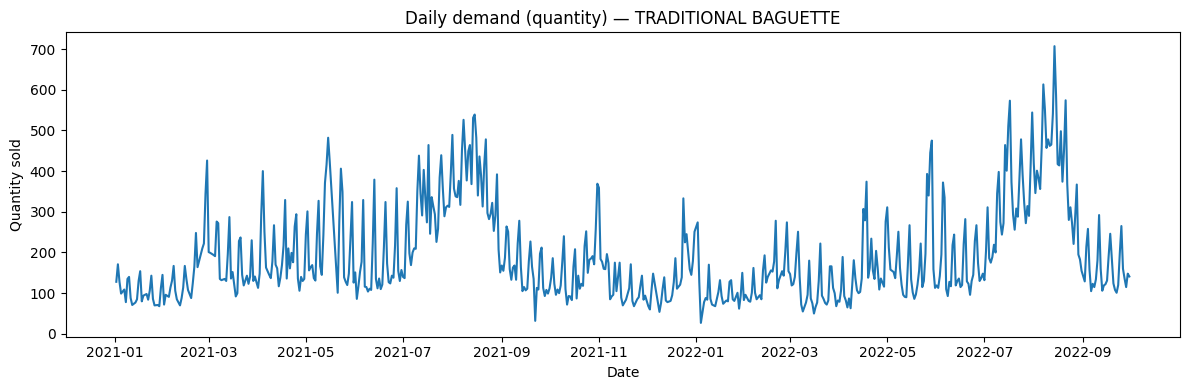

Saved: reports/figures/product_CROISSANT_quantity_timeseries.png


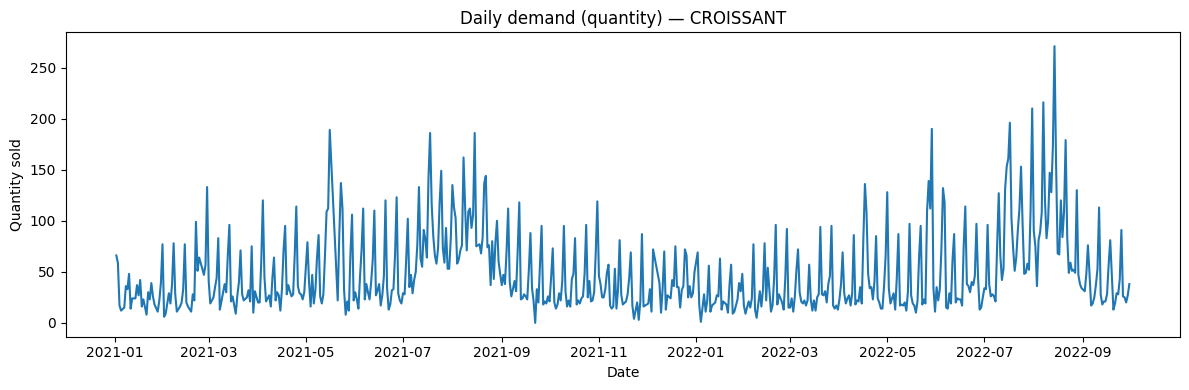

Saved: reports/figures/product_PAIN AU CHOCOLAT_quantity_timeseries.png


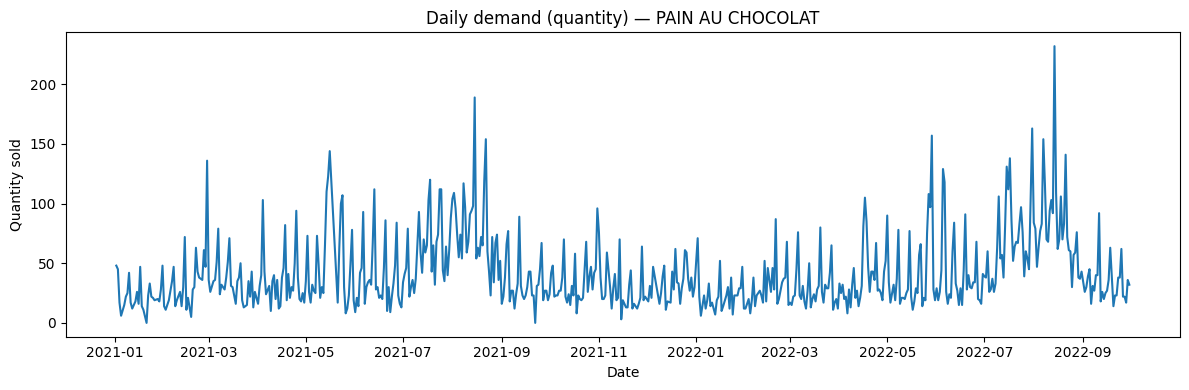

In [10]:
# PYTHON — Plot top product demand time series (quantity)
for p in top_products:
    s = qty_ts[p]
    plot_series(
        s,
        title=f"Daily demand (quantity) — {p}",
        ylabel="Quantity sold",
        save_name=f"product_{p}_quantity_timeseries.png"
    )

## 2) Weekday seasonality (product)

We compute the average quantity sold per weekday (Mon–Sun) for one representative product.

⸻


Saved: reports/figures/product_TRADITIONAL BAGUETTE_weekday_seasonality.png


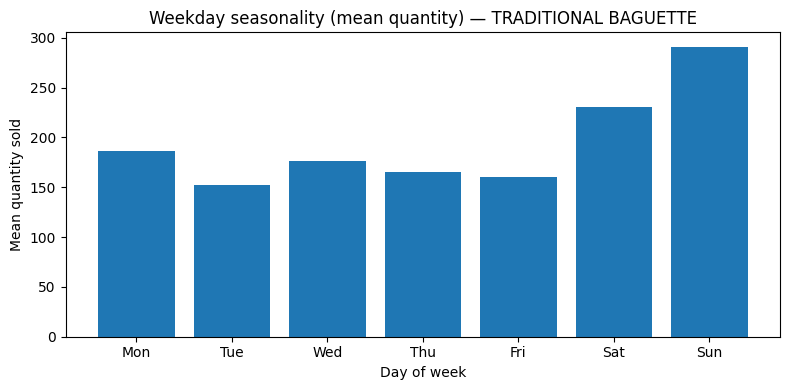

In [11]:
# PYTHON — Weekday seasonality for the most sold product
product_for_weekday = top_products[0]
means = weekday_seasonality(qty_ts[product_for_weekday])

plot_weekday_bar(
    means,
    title=f"Weekday seasonality (mean quantity) — {product_for_weekday}",
    ylabel="Mean quantity sold",
    save_name=f"product_{product_for_weekday}_weekday_seasonality.png"
)

## 3) ACF/PACF (product)

We plot ACF/PACF for one product series to illustrate:
	•	short-term dependence (lags 1, 2, …)
	•	weekly seasonality (often visible around lag 7)

Saved: reports/figures/product_TRADITIONAL BAGUETTE_acf.png


<Figure size 1000x400 with 0 Axes>

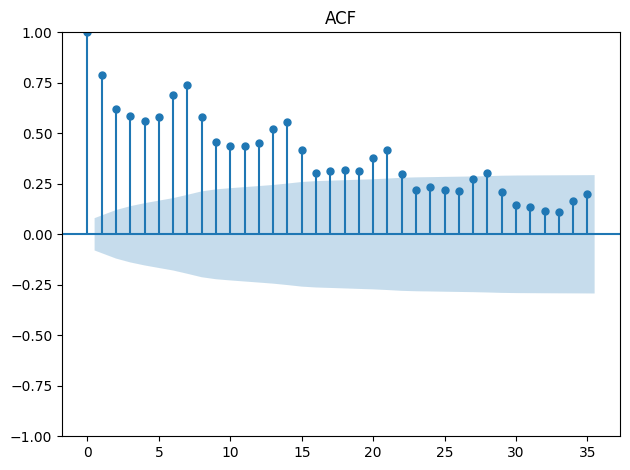

Saved: reports/figures/product_TRADITIONAL BAGUETTE_pacf.png


<Figure size 1000x400 with 0 Axes>

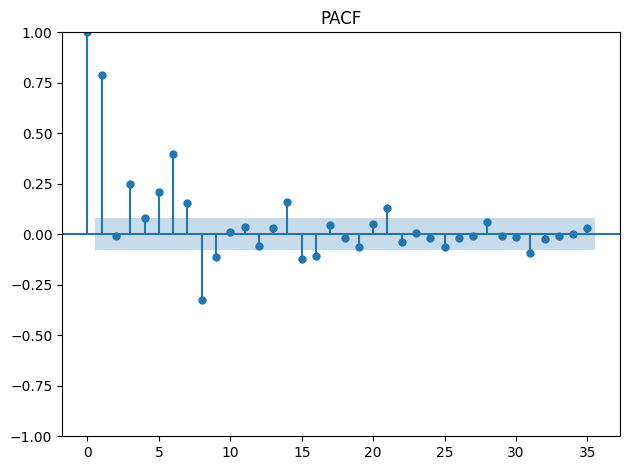

In [12]:
# PYTHON — ACF/PACF for one product
series_for_acf = qty_ts[top_products[0]]
plot_acf_pacf(series_for_acf, max_lag=35, save_prefix=f"product_{top_products[0]}")

In [13]:
# PYTHON — List exported figures
sorted(os.listdir(FIG_DIR))[:20]

['product_CROISSANT_quantity_timeseries.png',
 'product_PAIN AU CHOCOLAT_quantity_timeseries.png',
 'product_TRADITIONAL BAGUETTE_acf.png',
 'product_TRADITIONAL BAGUETTE_pacf.png',
 'product_TRADITIONAL BAGUETTE_quantity_timeseries.png',
 'product_TRADITIONAL BAGUETTE_weekday_seasonality.png']